<font face="Garamond">

<center> <font size="7" color="indigo"> Computational Data Mining – Homework 1  

<center> <font size="5" color="purple"> Investigation of Matrix Monitoring Methods for Accelerating Repetitive Pattern Identification Algorithms


<center> <img src="https://upload.wikimedia.org/wikipedia/commons/f/fa/Amirkabir-University-of-Technology-Logo.png" width="200"/>


<center> <font size="4" color="darkblue"> Amirkabir University of Technology – Fall 2025


In [ ]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 10

import time
from math import isfinite

from collections import defaultdict

from mlxtend.frequent_patterns import apriori, fpgrowth

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

<font face="Book Antiqua">

# Step 1 – Data Loading and Preprocessing

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
data = pd.read_excel(url)

In [ ]:
df = data.copy()

In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
print("InvoiceNo dtype:", df['InvoiceNo'].dtype)

print("\nSample InvoiceNos containing 'C':")
print(df[df['InvoiceNo'].astype(str).str.contains('C', case=False, na=False)]['InvoiceNo'].unique()[:20])

InvoiceNo dtype: object

Sample InvoiceNos containing 'C':
['C536379' 'C536383' 'C536391' 'C536506' 'C536543' 'C536548' 'C536606'
 'C536622' 'C536625' 'C536642' 'C536734' 'C536737' 'C536757' 'C536758'
 'C536760' 'C536807' 'C536812' 'C536814' 'C536815' 'C536816']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
after = len(df)
print(f"Step 1 - Remove credit invoices: removed {before - after} rows, remaining {after}")

before = len(df)
df = df[df['Quantity'] > 0]
after = len(df)
print(f"Step 2 - Remove non-positive quantities: removed {before - after} rows, remaining {after}")

before = len(df)
df = df.dropna()
after = len(df)
print(f"Step 3 - Drop NA: removed {before - after} rows, remaining {after}")

df = df.reset_index(drop=True)
print(f"Step 4 - Reset index: total rows {len(df)}")

Step 1 - Remove credit invoices: removed 9288 rows, remaining 532621
Step 2 - Remove non-positive quantities: removed 1336 rows, remaining 531285
Step 3 - Drop NA: removed 133361 rows, remaining 397924
Step 4 - Reset index: total rows 397924


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397924 entries, 0 to 397923
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.3+ MB


In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDate Range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())
print("\nUnique Customers:", df['CustomerID'].nunique())
print("Unique Products:", df['Description'].nunique())
print("Unique Invoices:", df['InvoiceNo'].nunique())
print("Unique Countries:", df['Country'].nunique())

Shape: (397924, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Date Range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00

Unique Customers: 4339
Unique Products: 3877
Unique Invoices: 18536
Unique Countries: 37


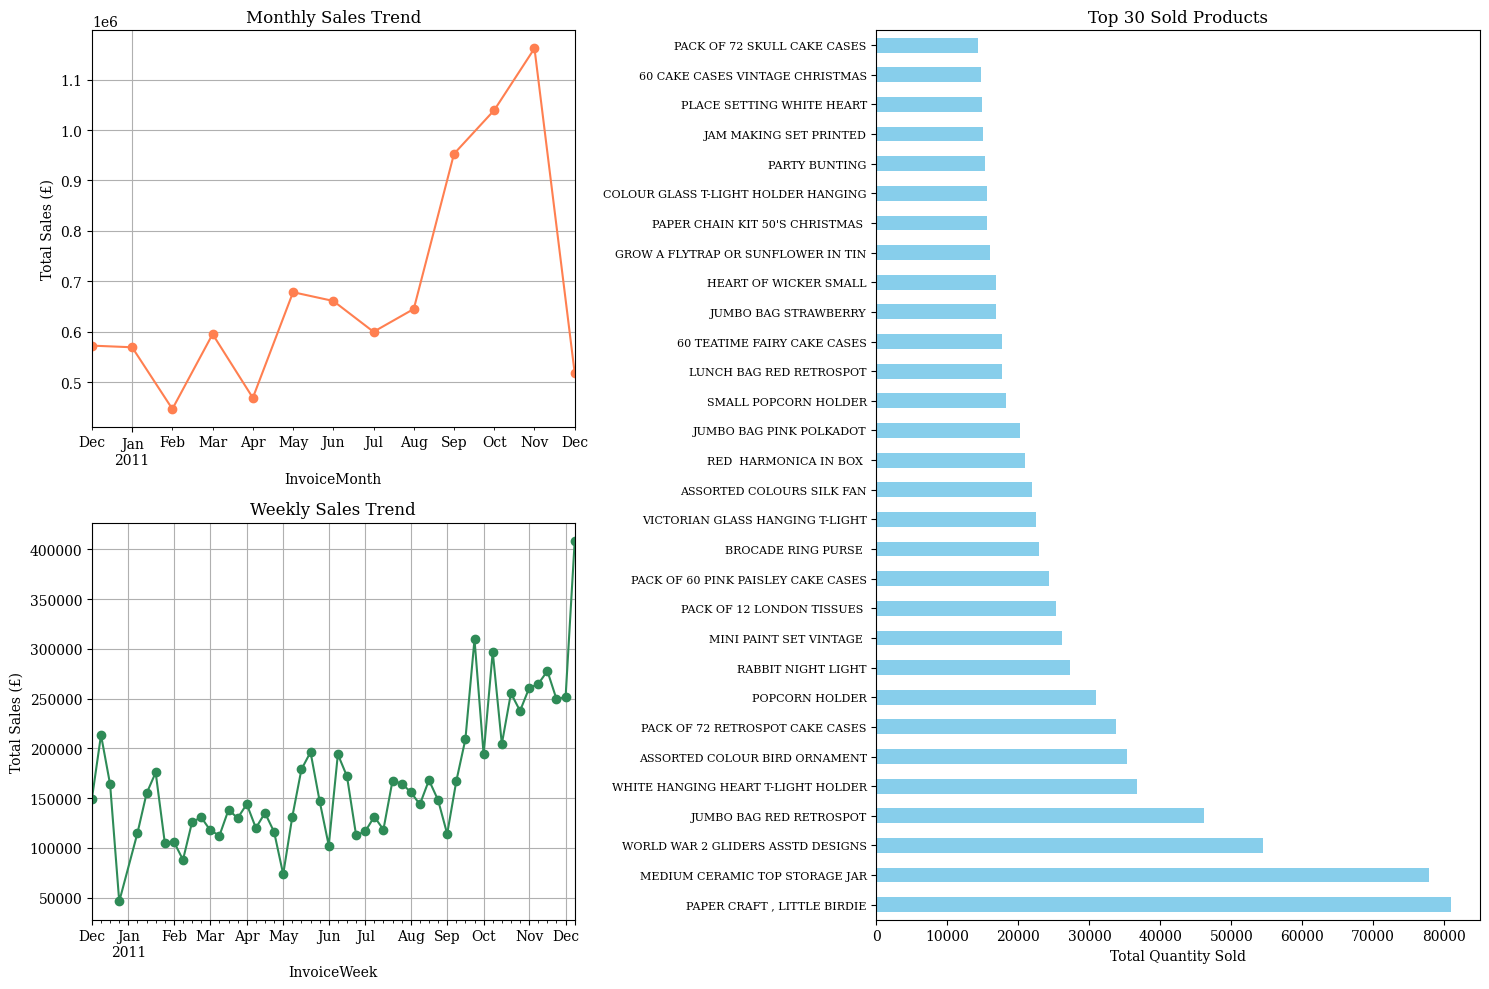

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['InvoiceWeek'] = df['InvoiceDate'].dt.to_period('W')

top_products = df.groupby('Description')['Quantity'].sum().nlargest(30)
monthly_sales = df.groupby('InvoiceMonth')['TotalPrice'].sum()
weekly_sales = df.groupby('InvoiceWeek')['TotalPrice'].sum()

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1.5])

ax1 = fig.add_subplot(gs[0, 0])
monthly_sales.plot(marker='o', color='coral', ax=ax1, title='Monthly Sales Trend')
ax1.set_ylabel('Total Sales (£)')
ax1.grid(True)

ax2 = fig.add_subplot(gs[1, 0])
weekly_sales.plot(marker='o', color='seagreen', ax=ax2, title='Weekly Sales Trend')
ax2.set_ylabel('Total Sales (£)')
ax2.grid(True)

ax3 = fig.add_subplot(gs[:, 1])
top_products.plot(kind='barh', color='skyblue', ax=ax3)
ax3.set_title('Top 30 Sold Products')
ax3.set_xlabel('Total Quantity Sold')
ax3.set_ylabel('')
ax3.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


<font face="Book Antiqua">

# Step 2 – Building the Item–Transaction Matrix

In [ ]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['Description'] = df['Description'].astype(str)
basket = (
    df.groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)
basket = basket.map(lambda x: 1 if x > 0 else 0)
print("Matrix shape:", basket.shape)

Matrix shape: (18536, 3877)


In [ ]:
with pd.option_context('display.max_rows', 12, 'display.max_columns', 12):
    display(basket.T)

InvoiceNo,536365,536366,536367,536368,536369,536370,...,581582,581583,581584,581585,581586,581587
Description,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0,0,0,0,0,0,...,0,0,0,0,0,0
50'S CHRISTMAS GIFT BAG LARGE,0,0,0,0,0,0,...,0,0,0,0,0,0
DOLLY GIRL BEAKER,0,0,0,0,0,0,...,0,0,0,0,0,0
I LOVE LONDON MINI BACKPACK,0,0,0,0,0,0,...,0,0,0,0,0,0
I LOVE LONDON MINI RUCKSACK,0,0,0,0,0,0,...,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZINC T-LIGHT HOLDER STARS SMALL,0,0,0,0,0,0,...,0,0,0,0,0,0
ZINC TOP 2 DOOR WOODEN SHELF,0,0,0,0,0,0,...,0,0,0,0,0,0
ZINC WILLIE WINKIE CANDLE STICK,0,0,0,0,0,0,...,0,0,0,1,0,0


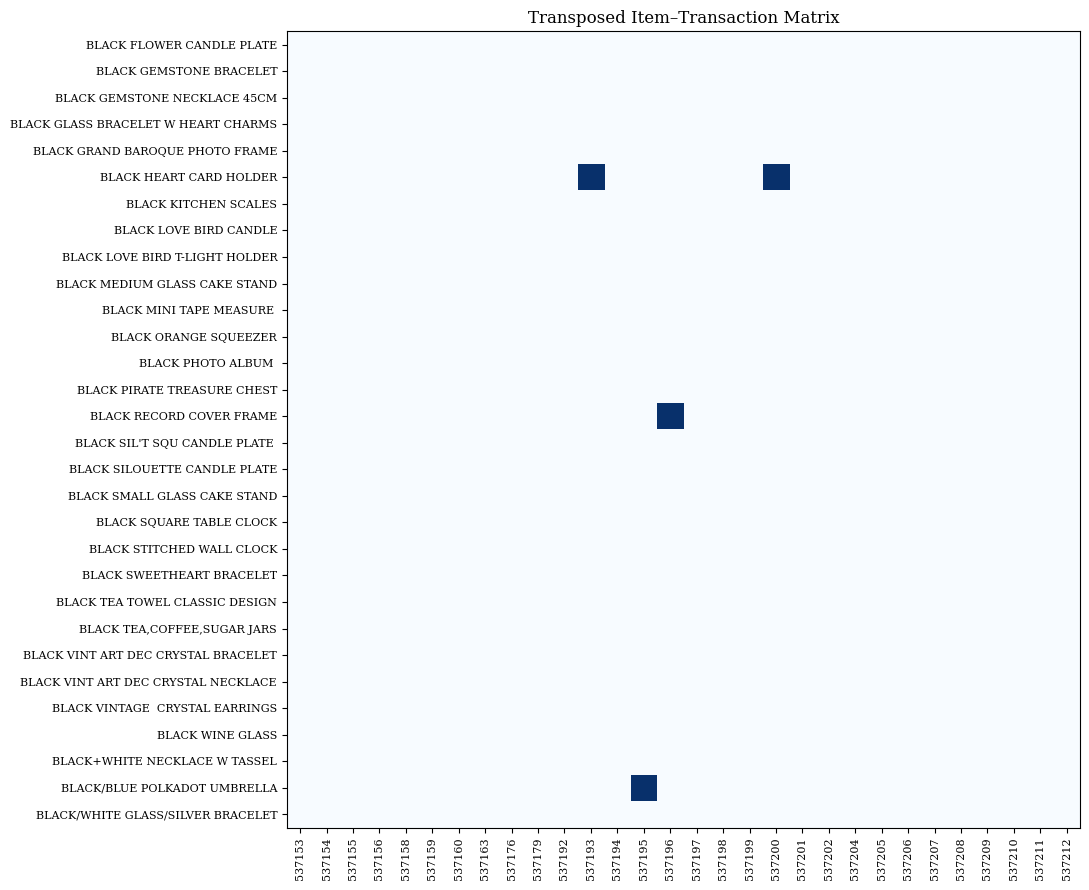

In [ ]:
sample = basket.iloc[360:390, 360:390].T
plt.figure(figsize=(11,9))
plt.imshow(sample, cmap="Blues", aspect="auto")
plt.title("Transposed Item–Transaction Matrix", fontsize=12, pad=6)
plt.xticks(range(len(sample.columns)), sample.columns, rotation=90, fontsize=8)
plt.yticks(range(len(sample.index)), sample.index, fontsize=8)
plt.tight_layout()
plt.show()

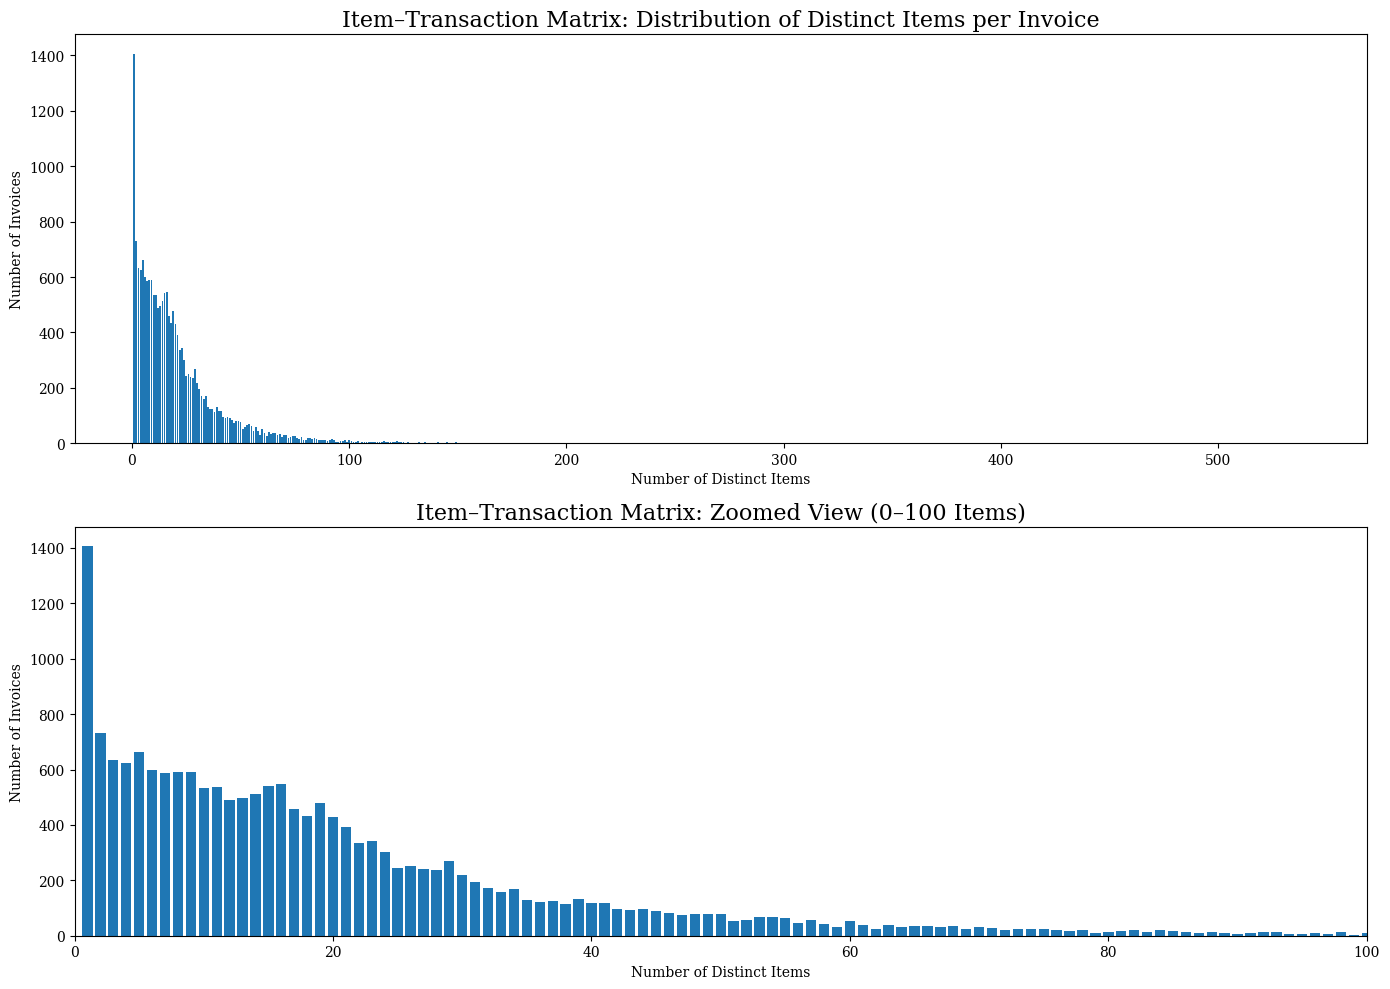

In [ ]:
row_sums = basket.sum(axis=1)
count_distribution = row_sums.value_counts().sort_index()

fig, axs = plt.subplots(2, 1, figsize=(14, 10))

axs[0].bar(count_distribution.index, count_distribution.values)
axs[0].set_title("Item–Transaction Matrix: Distribution of Distinct Items per Invoice", fontsize=16)
axs[0].set_xlabel("Number of Distinct Items")
axs[0].set_ylabel("Number of Invoices")

axs[1].bar(count_distribution.index, count_distribution.values)
axs[1].set_xlim(0, 100)
axs[1].set_title("Item–Transaction Matrix: Zoomed View (0–100 Items)", fontsize=16)
axs[1].set_xlabel("Number of Distinct Items")
axs[1].set_ylabel("Number of Invoices")

plt.tight_layout()
plt.show()

<font face="Book Antiqua">

# Step 3 – Data Stream Simulation

In [ ]:
df = df.sort_values('InvoiceDate')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('W')
batches = [g for _, g in df.groupby('InvoiceMonth')]
for i, batch in enumerate(batches[:]):
    print(f"Batch {i+1}: {batch['InvoiceMonth'].iloc[0]}, shape = {batch.shape}")

Batch 1: 2010-11-29/2010-12-05, shape = (7753, 11)
Batch 2: 2010-12-06/2010-12-12, shape = (9568, 11)
Batch 3: 2010-12-13/2010-12-19, shape = (7060, 11)
Batch 4: 2010-12-20/2010-12-26, shape = (1779, 11)
Batch 5: 2011-01-03/2011-01-09, shape = (5230, 11)
Batch 6: 2011-01-10/2011-01-16, shape = (4705, 11)
Batch 7: 2011-01-17/2011-01-23, shape = (4679, 11)
Batch 8: 2011-01-24/2011-01-30, shape = (5618, 11)
Batch 9: 2011-01-31/2011-02-06, shape = (5080, 11)
Batch 10: 2011-02-07/2011-02-13, shape = (3811, 11)
Batch 11: 2011-02-14/2011-02-20, shape = (5264, 11)
Batch 12: 2011-02-21/2011-02-27, shape = (5792, 11)
Batch 13: 2011-02-28/2011-03-06, shape = (5594, 11)
Batch 14: 2011-03-07/2011-03-13, shape = (5392, 11)
Batch 15: 2011-03-14/2011-03-20, shape = (6044, 11)
Batch 16: 2011-03-21/2011-03-27, shape = (6482, 11)
Batch 17: 2011-03-28/2011-04-03, shape = (6488, 11)
Batch 18: 2011-04-04/2011-04-10, shape = (6192, 11)
Batch 19: 2011-04-11/2011-04-17, shape = (6462, 11)
Batch 20: 2011-04-18/

<font face="Book Antiqua">

# Step 4 – Matrix Monitoring with Different Algorithms

In [ ]:
K = 50
FD_ELL = 50
rng = np.random.RandomState(42)

def batch_pca(X, k):
    mean = X.mean(axis=0)
    Xc = X - mean
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    r = Vt.shape[0]
    k_eff = min(k, r)
    comps = Vt[:k_eff, :]
    X_proj_core = Xc @ comps.T
    if k_eff < k:
        pad = np.zeros((X_proj_core.shape[0], k - k_eff), dtype=X_proj_core.dtype)
        X_proj = np.hstack([X_proj_core, pad])
    else:
        X_proj = X_proj_core
    return X_proj, comps, mean

summary = []

for i, batch in enumerate(batches, start=1):
    basket_b = batch.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack(fill_value=0)
    X = (basket_b > 0).astype(float).values
    if X.size == 0:
        print(f"Batch {i}: empty matrix, skipped")
        continue

    m, d = X.shape
    k = min(K, d)
    ell = min(FD_ELL, d)

    t0 = time.time()
    R = rng.normal(loc=0.0, scale=1.0/np.sqrt(k), size=(d, k))
    X_rp = X @ R
    t_rp = time.time() - t0

    t0 = time.time()
    X_ipca, ipca_comps, ipca_mean = batch_pca(X, k)
    t_ipca = time.time() - t0

    t0 = time.time()
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    s_top = s[:ell]
    B_fd = np.diag(s_top) @ Vt[:ell, :]
    t_fd = time.time() - t0

    summary.append({'batch_index': i, 'rows': m, 'cols': d, 'k': k, 'ell': ell, 'rp_time': t_rp, 'ipca_time': t_ipca, 'fd_time': t_fd, 'X_rp': X_rp, 'X_ipca': X_ipca, 'B_fd': B_fd})
    print(f"Batch {i}: rows={m}, cols={d} | RP(k={k}) {t_rp:.3f}s | IPCA {t_ipca:.3f}s | FD(ell={ell}) {t_fd:.3f}s")

Batch 1: rows=402, cols=1712 | RP(k=50) 0.006s | IPCA 0.247s | FD(ell=50) 0.201s
Batch 2: rows=489, cols=1788 | RP(k=50) 0.009s | IPCA 0.371s | FD(ell=50) 0.319s
Batch 3: rows=401, cols=1745 | RP(k=50) 0.008s | IPCA 0.220s | FD(ell=50) 0.207s
Batch 4: rows=108, cols=916 | RP(k=50) 0.003s | IPCA 0.015s | FD(ell=50) 0.020s
Batch 5: rows=224, cols=1446 | RP(k=50) 0.005s | IPCA 0.115s | FD(ell=50) 0.075s
Batch 6: rows=233, cols=1445 | RP(k=50) 0.005s | IPCA 0.078s | FD(ell=50) 0.069s
Batch 7: rows=206, cols=1434 | RP(k=50) 0.005s | IPCA 0.067s | FD(ell=50) 0.059s
Batch 8: rows=267, cols=1457 | RP(k=50) 0.005s | IPCA 0.131s | FD(ell=50) 0.196s
Batch 9: rows=272, cols=1395 | RP(k=50) 0.009s | IPCA 0.230s | FD(ell=50) 0.251s
Batch 10: rows=198, cols=1326 | RP(k=50) 0.007s | IPCA 0.164s | FD(ell=50) 0.624s
Batch 11: rows=267, cols=1492 | RP(k=50) 0.021s | IPCA 0.240s | FD(ell=50) 0.576s
Batch 12: rows=267, cols=1492 | RP(k=50) 0.007s | IPCA 0.409s | FD(ell=50) 0.200s
Batch 13: rows=267, cols=1

In [ ]:
timing_df = pd.DataFrame([{'batch': s['batch_index'], 'rows': s['rows'], 'cols': s['cols'], 'rp_time': s['rp_time'], 'ipca_time': s['ipca_time'], 'fd_time': s['fd_time']} for s in summary])
timing_df

,batch,rows,cols,rp_time,ipca_time,fd_time
0,1,402,1712,0.006471,0.246711,0.201381
1,2,489,1788,0.008622,0.370628,0.319458
2,3,401,1745,0.007673,0.220380,0.206979
3,4,108,916,0.002787,0.015390,0.019629
4,5,224,1446,0.005105,0.115318,0.075407
5,6,233,1445,0.005450,0.077678,0.068887
6,7,206,1434,0.005114,0.066569,0.059137
7,8,267,1457,0.005417,0.131350,0.195603
8,9,272,1395,0.009243,0.230202,0.250863
9,10,198,1326,0.006605,0.163511,0.624344


<font face="Book Antiqua">

# Step 5 – Computing Analytical Metrics

In [ ]:
metrics = []
rng_seed = 42

for s in summary:
    i = s['batch_index']
    m = s['rows']
    d = s['cols']
    k = s['k']
    ell = s['ell']

    X_rp = s['X_rp']      # (m x k)
    X_ipca = s['X_ipca']  # (m x k)
    B_fd = s['B_fd']      # (ell x d)

    # get corresponding batch (batch_index is 1-based)
    try:
        batch_df = batches[i - 1]
    except Exception:
        continue  # skip if batch not found

    # rebuild binary matrix X (m x d)
    basket_b = (
        batch_df.groupby(['InvoiceNo', 'Description'])['Quantity']
                .sum()
                .unstack(fill_value=0)
    )
    X = (basket_b > 0).astype(float).values
    if X.size == 0:
        continue  # skip empty batches

    # baseline quantities
    frob_X = np.linalg.norm(X, ord='fro')
    total_var = np.sum(np.var(X, axis=0, ddof=0))
    if total_var <= 0:
        total_var = 1e-12

    # 1) Random Projection metrics
    rng = np.random.default_rng(rng_seed)
    R = rng.normal(loc=0.0, scale=1.0 / np.sqrt(max(1, k)), size=(d, k))
    ev_rp = np.sum(np.var(X_rp, axis=0, ddof=0)) / total_var

    try:
        R_pinv = np.linalg.pinv(R)
        Xhat_rp = X_rp @ R_pinv
        err_rp = np.linalg.norm(X - Xhat_rp, ord='fro') / max(1e-12, frob_X)
        frob_Xhat_rp = np.linalg.norm(Xhat_rp, ord='fro')
    except Exception:
        err_rp = np.nan
        frob_Xhat_rp = np.nan

    # 2) Incremental PCA metrics
    ev_ipca = np.sum(np.var(X_ipca, axis=0, ddof=0)) / total_var
    try:
        W, *_ = np.linalg.lstsq(X, X_ipca, rcond=None)
        W_pinv = np.linalg.pinv(W)
        Xhat_ipca = X_ipca @ W_pinv
        err_ipca = np.linalg.norm(X - Xhat_ipca, ord='fro') / max(1e-12, frob_X)
        frob_Xhat_ipca = np.linalg.norm(Xhat_ipca, ord='fro')
    except Exception:
        err_ipca = np.nan
        frob_Xhat_ipca = np.nan

    # 3) Frequent Directions metrics
    try:
        Ub, sb, Vtb = np.linalg.svd(B_fd, full_matrices=False)
        V_fd = Vtb.T[:, :Vtb.shape[0]]
        Z_fd = X @ V_fd
        ev_fd = np.sum(np.var(Z_fd, axis=0, ddof=0)) / total_var

        Xhat_fd = (X @ V_fd) @ V_fd.T
        err_fd = np.linalg.norm(X - Xhat_fd, ord='fro') / max(1e-12, frob_X)
        frob_Xhat_fd = np.linalg.norm(Xhat_fd, ord='fro')
    except Exception:
        ev_fd = np.nan
        err_fd = np.nan
        frob_Xhat_fd = np.nan

    metrics.append({
        'batch': i,
        'rows': m,
        'cols': d,
        'frob_X': frob_X,
        'rp_explained_var': float(ev_rp),
        'ipca_explained_var': float(ev_ipca),
        'fd_explained_var': float(ev_fd),
        'rp_recon_err': float(err_rp),
        'ipca_recon_err': float(err_ipca),
        'fd_recon_err': float(err_fd),
        'rp_frob_approx': float(frob_Xhat_rp) if isfinite(frob_Xhat_rp) else np.nan,
        'ipca_frob_approx': float(frob_Xhat_ipca) if isfinite(frob_Xhat_ipca) else np.nan,
        'fd_frob_approx': float(frob_Xhat_fd) if isfinite(frob_Xhat_fd) else np.nan,
        'rp_time': s.get('rp_time', np.nan),
        'ipca_time': s.get('ipca_time', np.nan),
        'fd_time': s.get('fd_time', np.nan),
    })

df_metrics = pd.DataFrame(metrics).sort_values('batch').reset_index(drop=True)

In [ ]:
df_metrics

,batch,rows,cols,frob_X,rp_explained_var,ipca_explained_var,fd_explained_var,rp_recon_err,ipca_recon_err,fd_recon_err,rp_frob_approx,ipca_frob_approx,fd_frob_approx,rp_time,ipca_time,fd_time
0,1,402,1712,85.953476,0.977898,0.524941,0.523756,1.014212,0.720188,0.681257,14.745825,59.632820,62.921758,0.006471,0.246711,0.201381
1,2,489,1788,96.062480,1.012937,0.445661,0.444785,1.014257,0.769287,0.734971,16.402304,61.374897,65.139794,0.008622,0.370628,0.319458
2,3,401,1745,83.162492,0.986677,0.471117,0.469953,1.014296,0.748842,0.719178,14.116204,55.115782,57.783409,0.007673,0.220380,0.206979
3,4,108,916,41.952354,1.014410,0.865067,0.863597,1.028104,0.439613,0.364224,10.118696,37.681076,39.070700,0.002787,0.015390,0.019629
4,5,224,1446,71.791364,0.997345,0.625476,0.624032,1.017876,0.655956,0.603236,13.588619,54.188090,57.258135,0.005105,0.115318,0.075407
5,6,233,1445,67.727395,1.015412,0.609355,0.608121,1.016941,0.660540,0.617791,12.954506,50.849099,53.256901,0.005450,0.077678,0.068887
6,7,206,1434,67.623960,0.982159,0.642514,0.640936,1.018062,0.638610,0.590472,12.691382,52.038718,54.576451,0.005114,0.066569,0.059137
7,8,267,1457,73.918874,1.007613,0.554265,0.552393,1.017691,0.700321,0.658840,13.900877,52.765354,55.607924,0.005417,0.131350,0.195603
8,9,272,1395,70.604532,0.979740,0.569452,0.568143,1.017492,0.691287,0.648001,13.391302,51.017422,53.775225,0.009243,0.230202,0.250863
9,10,198,1326,61.106464,0.991288,0.665824,0.664251,1.019895,0.618365,0.572031,11.992677,48.023046,50.121492,0.006605,0.163511,0.624344


<font face="Book Antiqua">

# Step 6 – Plotting & Analysis

<font face="Book Antiqua">

## 1) Reconstruction Error Over Time

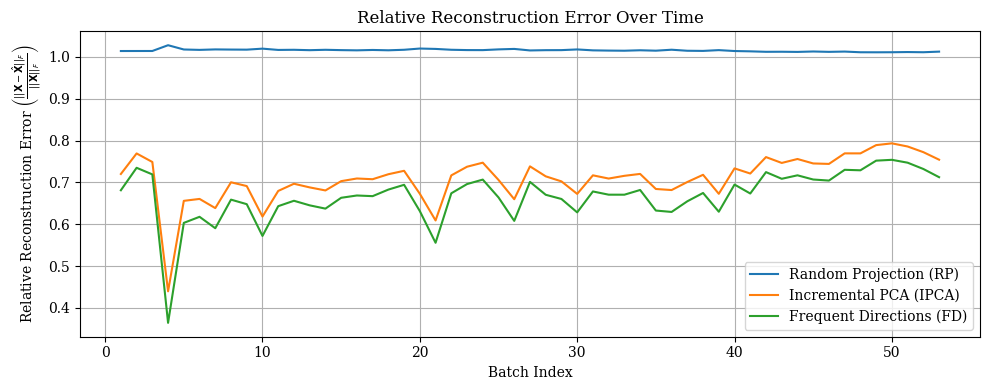

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df_metrics['batch'], df_metrics['rp_recon_err'], label=r'Random Projection (RP)')
plt.plot(df_metrics['batch'], df_metrics['ipca_recon_err'], label=r'Incremental PCA (IPCA)')
plt.plot(df_metrics['batch'], df_metrics['fd_recon_err'], label=r'Frequent Directions (FD)')
plt.xlabel('Batch Index')
plt.ylabel(r'Relative Reconstruction Error $\left( \frac{||\mathbf{X} - \hat{\mathbf{X}}||_F}{||\mathbf{X}||_F} \right)$')
plt.title('Relative Reconstruction Error Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<font face="Book Antiqua">

## 2) Explained Variance Ratio Over Time

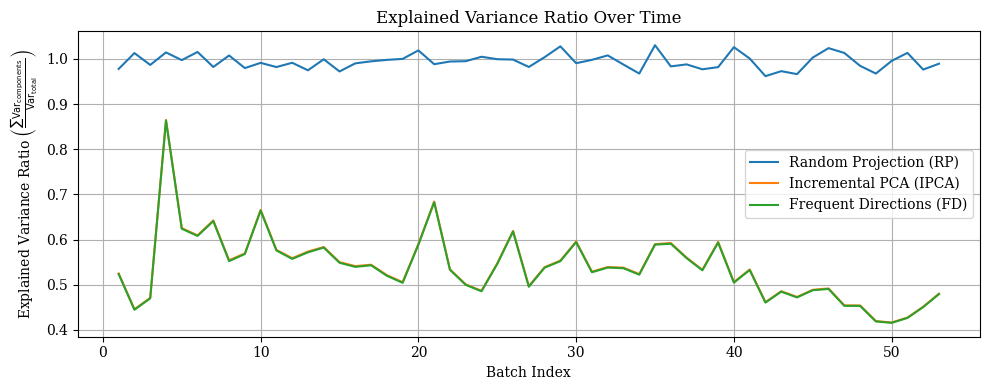

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df_metrics['batch'], df_metrics['rp_explained_var'], label=r'Random Projection (RP)')
plt.plot(df_metrics['batch'], df_metrics['ipca_explained_var'], label=r'Incremental PCA (IPCA)')
plt.plot(df_metrics['batch'], df_metrics['fd_explained_var'], label=r'Frequent Directions (FD)')
plt.xlabel('Batch Index')
plt.ylabel(r'Explained Variance Ratio $\left( \frac{\sum \mathrm{Var}_{\text{components}}}{\mathrm{Var}_{\text{total}}} \right)$')
plt.title('Explained Variance Ratio Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<font face="Book Antiqua">

## 3) Frobenius Norms: Original vs Approx


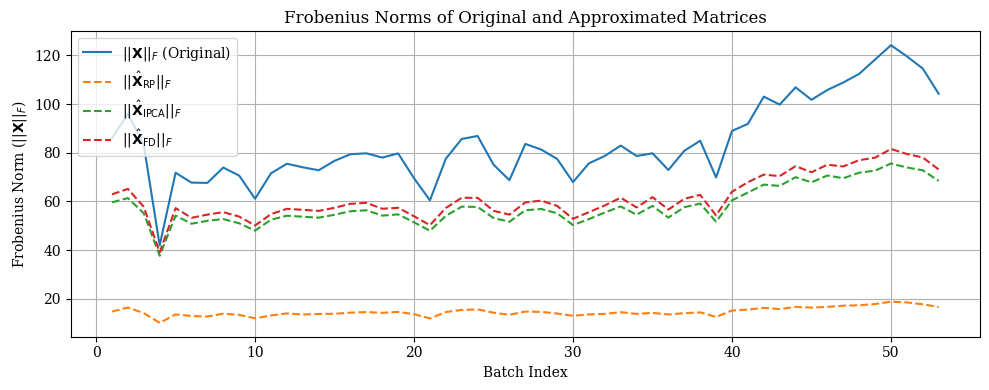

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df_metrics['batch'], df_metrics['frob_X'], label=r'$||\mathbf{X}||_F$ (Original)')
plt.plot(df_metrics['batch'], df_metrics['rp_frob_approx'], linestyle='--', label=r'$||\hat{\mathbf{X}}_{\mathrm{RP}}||_F$')
plt.plot(df_metrics['batch'], df_metrics['ipca_frob_approx'], linestyle='--', label=r'$||\hat{\mathbf{X}}_{\mathrm{IPCA}}||_F$')
plt.plot(df_metrics['batch'], df_metrics['fd_frob_approx'], linestyle='--', label=r'$||\hat{\mathbf{X}}_{\mathrm{FD}}||_F$')
plt.xlabel('Batch Index')
plt.ylabel(r'Frobenius Norm ($||\mathbf{X}||_F$)')
plt.title('Frobenius Norms of Original and Approximated Matrices')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<font face="Book Antiqua">

## 4) Timing Comparison (Median or Mean per Method)

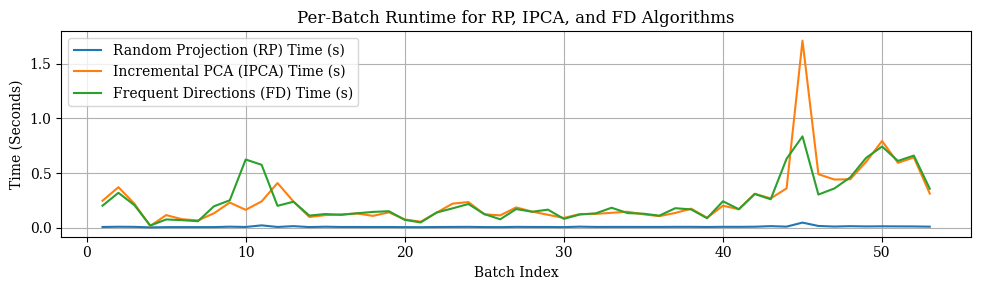

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(df_metrics['batch'], df_metrics['rp_time'], label='Random Projection (RP) Time (s)')
plt.plot(df_metrics['batch'], df_metrics['ipca_time'], label='Incremental PCA (IPCA) Time (s)')
plt.plot(df_metrics['batch'], df_metrics['fd_time'], label='Frequent Directions (FD) Time (s)')
plt.xlabel('Batch Index')
plt.ylabel('Time (Seconds)')
plt.title('Per-Batch Runtime for RP, IPCA, and FD Algorithms')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<font face="Book Antiqua">

## 5) Summary Statistics

In [ ]:
summary_stats = {
    'rp_mean_err': df_metrics['rp_recon_err'].mean(),
    'ipca_mean_err': df_metrics['ipca_recon_err'].mean(),
    'fd_mean_err': df_metrics['fd_recon_err'].mean(),
    'rp_mean_ev': df_metrics['rp_explained_var'].mean(),
    'ipca_mean_ev': df_metrics['ipca_explained_var'].mean(),
    'fd_mean_ev': df_metrics['fd_explained_var'].mean(),
    'rp_mean_time': df_metrics['rp_time'].mean(),
    'ipca_mean_time': df_metrics['ipca_time'].mean(),
    'fd_mean_time': df_metrics['fd_time'].mean(),
}
print('\nSummary Stats (Means)')
for k,v in summary_stats.items():
    print(f"{k}: {v:.4f}")


Summary Stats (Means)
rp_mean_err: 1.0157
ipca_mean_err: 0.7094
fd_mean_err: 0.6671
rp_mean_ev: 0.9941
ipca_mean_ev: 0.5400
fd_mean_ev: 0.5388
rp_mean_time: 0.0089
ipca_mean_time: 0.2499
fd_mean_time: 0.2463


<font face="Book Antiqua">

# Step 7 – Frequent Pattern Mining

In [ ]:
MIN_SUPPORT = 0.02
MAX_ITEMSET_LEN = 3
RP_SEED = 42
BINARY_THRESHOLD = 0.5

def itemsets_from_fpresult(fp_df, max_len=None):
    if fp_df is None or fp_df.shape[0] == 0:
        return set()
    if max_len is None:
        return set(fp_df['itemsets'].apply(lambda x: frozenset(x)))
    else:
        return set(fp_df[fp_df['itemsets'].apply(lambda s: len(s) <= max_len)]['itemsets'].apply(lambda x: frozenset(x)))

def support_map_from_fpresult(fp_df):
    if fp_df is None or fp_df.shape[0] == 0:
        return {}
    return {frozenset(x): float(s) for x, s in zip(fp_df['itemsets'], fp_df['support'])}

def avg_support_diff(ref_df, pred_df):
    ref_map = support_map_from_fpresult(ref_df)
    pred_map = support_map_from_fpresult(pred_df)
    common = set(ref_map.keys()) & set(pred_map.keys())
    if len(common) == 0:
        return np.nan
    diffs = [abs(ref_map[it] - pred_map[it]) for it in common]
    return float(np.mean(diffs))

def mine_both(df_bool_input, min_support=MIN_SUPPORT, max_len=MAX_ITEMSET_LEN):
    t0 = time.time()
    apr = apriori(df_bool_input, min_support=min_support, use_colnames=True, verbose=0)
    t_ap = time.time() - t0
    apr_k = apr[apr['itemsets'].apply(lambda s: len(s) <= max_len)]
    t0 = time.time()
    fpg = fpgrowth(df_bool_input, min_support=min_support, use_colnames=True, verbose=0)
    t_fp = time.time() - t0
    fpg_k = fpg[fpg['itemsets'].apply(lambda s: len(s) <= max_len)]
    return {'apriori_df': apr_k, 'apriori_time': t_ap, 'fpgrowth_df': fpg_k, 'fpgrowth_time': t_fp}

results = []

for s in summary:
    batch_idx = s['batch_index']
    batch_df = batches[batch_idx - 1]
    basket_b = batch_df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack(fill_value=0)
    df_bool = (basket_b > 0)
    items = list(df_bool.columns)
    m, d = df_bool.shape
    if d == 0 or m == 0:
        continue

    t0 = time.time()
    fp_apriori_orig = apriori(df_bool, min_support=MIN_SUPPORT, use_colnames=True, verbose=0)
    t_apriori_orig = time.time() - t0
    t0 = time.time()
    fp_fpgrowth_orig = fpgrowth(df_bool, min_support=MIN_SUPPORT, use_colnames=True, verbose=0)
    t_fpgrowth_orig = time.time() - t0
    fp_fpgrowth_orig_k = fp_fpgrowth_orig[fp_fpgrowth_orig['itemsets'].apply(lambda s: len(s) <= MAX_ITEMSET_LEN)]
    fp_apriori_orig_k = fp_apriori_orig[fp_apriori_orig['itemsets'].apply(lambda s: len(s) <= MAX_ITEMSET_LEN)]

    orig_itemsets_apriori = itemsets_from_fpresult(fp_apriori_orig_k)
    orig_supports_apriori = support_map_from_fpresult(fp_apriori_orig_k)
    orig_itemsets_fpgrowth = itemsets_from_fpresult(fp_fpgrowth_orig_k)
    orig_supports_fpgrowth = support_map_from_fpresult(fp_fpgrowth_orig_k)

    X = (basket_b > 0).astype(float).values

    X_rp = s['X_rp']
    k_rp = X_rp.shape[1]
    rng = np.random.default_rng(RP_SEED)
    R = rng.normal(loc=0.0, scale=1.0 / np.sqrt(max(1, k_rp)), size=(d, k_rp))
    R_pinv = np.linalg.pinv(R)
    Xhat_rp = X_rp @ R_pinv
    df_rp_bin = pd.DataFrame((Xhat_rp > BINARY_THRESHOLD).astype(int), columns=items, index=basket_b.index).astype(bool)

    X_ipca = s['X_ipca']
    W, *_ = np.linalg.lstsq(X, X_ipca, rcond=None)
    W_pinv = np.linalg.pinv(W)
    Xhat_ipca = X_ipca @ W_pinv
    df_ipca_bin = pd.DataFrame((Xhat_ipca > BINARY_THRESHOLD).astype(int), columns=items, index=basket_b.index).astype(bool)

    B_fd = s['B_fd']
    _, _, Vtb = np.linalg.svd(B_fd, full_matrices=False)
    V_fd = Vtb.T
    Xhat_fd = (X @ V_fd) @ V_fd.T
    df_fd_bin = pd.DataFrame((Xhat_fd > BINARY_THRESHOLD).astype(int), columns=items, index=basket_b.index).astype(bool)

    mine_orig = {'apriori_df': fp_apriori_orig_k, 'apriori_time': t_apriori_orig, 'fpgrowth_df': fp_fpgrowth_orig_k, 'fpgrowth_time': t_fpgrowth_orig}
    mine_rp = mine_both(df_rp_bin)
    mine_ipca = mine_both(df_ipca_bin)
    mine_fd = mine_both(df_fd_bin)

    def compare_sets(true_sets, pred_sets):
        if len(pred_sets) == 0 and len(true_sets) == 0:
            return (1.0, 1.0, 1.0)
        if len(pred_sets) == 0:
            return (0.0, 0.0, 0.0)
        tp = len(true_sets & pred_sets)
        prec = tp / len(pred_sets) if len(pred_sets) > 0 else 0.0
        rec = tp / len(true_sets) if len(true_sets) > 0 else 0.0
        f1 = (2*prec*rec/(prec+rec)) if (prec+rec) > 0 else 0.0
        return (prec, rec, f1)

    ref_sets = orig_itemsets_apriori
    rp_sets_apriori = itemsets_from_fpresult(mine_rp['apriori_df'])
    ipca_sets_apriori = itemsets_from_fpresult(mine_ipca['apriori_df'])
    fd_sets_apriori = itemsets_from_fpresult(mine_fd['apriori_df'])

    rp_prec, rp_rec, rp_f1 = compare_sets(ref_sets, rp_sets_apriori)
    ipca_prec, ipca_rec, ipca_f1 = compare_sets(ref_sets, ipca_sets_apriori)
    fd_prec, fd_rec, fd_f1 = compare_sets(ref_sets, fd_sets_apriori)

    rp_support_diff = avg_support_diff(mine_orig['apriori_df'], mine_rp['apriori_df'])
    ipca_support_diff = avg_support_diff(mine_orig['apriori_df'], mine_ipca['apriori_df'])
    fd_support_diff = avg_support_diff(mine_orig['apriori_df'], mine_fd['apriori_df'])

    results.append({
        'batch': batch_idx,
        'rows': m,
        'cols': d,
        'orig_apriori_count': len(orig_itemsets_apriori),
        'orig_apriori_time': t_apriori_orig,
        'orig_fpgrowth_count': len(orig_itemsets_fpgrowth),
        'orig_fpgrowth_time': t_fpgrowth_orig,
        'rp_apriori_count': len(rp_sets_apriori),
        'rp_apriori_time': mine_rp['apriori_time'],
        'rp_apriori_prec': rp_prec, 'rp_apriori_rec': rp_rec, 'rp_apriori_f1': rp_f1,
        'rp_support_diff': rp_support_diff,
        'ipca_apriori_count': len(ipca_sets_apriori),
        'ipca_apriori_time': mine_ipca['apriori_time'],
        'ipca_apriori_prec': ipca_prec, 'ipca_apriori_rec': ipca_rec, 'ipca_apriori_f1': ipca_f1,
        'ipca_support_diff': ipca_support_diff,
        'fd_apriori_count': len(fd_sets_apriori),
        'fd_apriori_time': mine_fd['apriori_time'],
        'fd_apriori_prec': fd_prec, 'fd_apriori_rec': fd_rec, 'fd_apriori_f1': fd_f1,
        'fd_support_diff': fd_support_diff,
        'orig_sample_itemsets': list(sorted(map(lambda s: tuple(sorted(s)), orig_itemsets_apriori))[:10]),
        'rp_sample_itemsets': list(sorted(map(lambda s: tuple(sorted(s)), rp_sets_apriori))[:10]),
        'ipca_sample_itemsets': list(sorted(map(lambda s: tuple(sorted(s)), ipca_sets_apriori))[:10]),
        'fd_sample_itemsets': list(sorted(map(lambda s: tuple(sorted(s)), fd_sets_apriori))[:10]),
    })

    print(f"Batch {batch_idx}: orig_apriori={len(orig_itemsets_apriori)} rp_apriori={len(rp_sets_apriori)} ipca_apriori={len(ipca_sets_apriori)} fd_apriori={len(fd_sets_apriori)}")

Batch 1: orig_apriori=929 rp_apriori=0 ipca_apriori=758 fd_apriori=780
Batch 2: orig_apriori=387 rp_apriori=0 ipca_apriori=104 fd_apriori=162
Batch 3: orig_apriori=230 rp_apriori=0 ipca_apriori=56 fd_apriori=85
Batch 4: orig_apriori=413 rp_apriori=0 ipca_apriori=318 fd_apriori=342
Batch 5: orig_apriori=865 rp_apriori=0 ipca_apriori=344 fd_apriori=543
Batch 6: orig_apriori=492 rp_apriori=0 ipca_apriori=219 fd_apriori=258
Batch 7: orig_apriori=496 rp_apriori=0 ipca_apriori=213 fd_apriori=273
Batch 8: orig_apriori=490 rp_apriori=0 ipca_apriori=185 fd_apriori=253
Batch 9: orig_apriori=417 rp_apriori=0 ipca_apriori=131 fd_apriori=197
Batch 10: orig_apriori=700 rp_apriori=0 ipca_apriori=344 fd_apriori=439
Batch 11: orig_apriori=421 rp_apriori=0 ipca_apriori=143 fd_apriori=214
Batch 12: orig_apriori=458 rp_apriori=0 ipca_apriori=134 fd_apriori=188
Batch 13: orig_apriori=527 rp_apriori=0 ipca_apriori=149 fd_apriori=208
Batch 14: orig_apriori=509 rp_apriori=0 ipca_apriori=191 fd_apriori=253
Bat

In [ ]:
df_fp_compare = pd.DataFrame(results).sort_values('batch').reset_index(drop=True)
df_fp_compare

,batch,rows,cols,orig_apriori_count,orig_apriori_time,orig_fpgrowth_count,orig_fpgrowth_time,rp_apriori_count,rp_apriori_time,rp_apriori_prec,...,fd_apriori_count,fd_apriori_time,fd_apriori_prec,fd_apriori_rec,fd_apriori_f1,fd_support_diff,orig_sample_itemsets,rp_sample_itemsets,ipca_sample_itemsets,fd_sample_itemsets
0,1,402,1712,929,0.591416,929,59.822488,0,0.007038,0.0,...,780,1.251184,0.956410,0.803014,0.873025,0.006699,"[( SET 2 TEA TOWELS I LOVE LONDON ,), (10 COLO...",[],"[(60 CAKE CASES VINTAGE CHRISTMAS,), (ALARM CL...","[(6 RIBBONS RUSTIC CHARM,), (60 CAKE CASES VIN..."
1,2,489,1788,387,0.086709,387,0.288949,0,0.007810,0.0,...,162,0.018172,0.987654,0.413437,0.582878,0.008410,"[( SET 2 TEA TOWELS I LOVE LONDON ,), (12 PENC...",[],"[(60 CAKE CASES VINTAGE CHRISTMAS,), (60 TEATI...","[(3 HEARTS HANGING DECORATION RUSTIC,), (60 CA..."
2,3,401,1745,230,0.035958,230,0.104462,0,0.010845,0.0,...,85,0.017459,0.988235,0.365217,0.533333,0.010539,"[(12 PENCILS TALL TUBE RED RETROSPOT,), (3 HEA...",[],"[(ALARM CLOCK BAKELIKE PINK,), (ALARM CLOCK BA...","[(72 SWEETHEART FAIRY CAKE CASES,), (ALARM CLO..."
3,4,108,916,413,0.051751,413,0.177864,0,0.004264,0.0,...,342,0.038038,1.000000,0.828087,0.905960,0.002193,"[( SET 2 TEA TOWELS I LOVE LONDON ,), (3 HOOK ...",[],"[(3 HOOK PHOTO SHELF ANTIQUE WHITE,), (60 TEAT...","[(3 HOOK PHOTO SHELF ANTIQUE WHITE,), (60 TEAT..."
4,5,224,1446,865,0.191774,865,0.773633,0,0.014713,0.0,...,543,0.049376,0.957643,0.601156,0.738636,0.005117,"[(10 COLOUR SPACEBOY PEN,), (12 PENCILS SMALL ...",[],"[(20 DOLLY PEGS RETROSPOT,), (200 RED + WHITE ...","[(20 DOLLY PEGS RETROSPOT,), (3 HOOK PHOTO SHE..."
5,6,233,1445,492,0.073476,492,0.187967,0,0.006005,0.0,...,258,0.024705,1.000000,0.524390,0.688000,0.006987,"[( SET 2 TEA TOWELS I LOVE LONDON ,), (12 DAIS...",[],"[( SET 2 TEA TOWELS I LOVE LONDON ,), (3 PIECE...","[( SET 2 TEA TOWELS I LOVE LONDON ,), (3 PIECE..."
6,7,206,1434,496,0.065245,496,0.183523,0,0.005728,0.0,...,273,0.023938,0.996337,0.548387,0.707412,0.007567,"[(12 PENCILS SMALL TUBE RED RETROSPOT,), (12 P...",[],"[(12 PENCILS SMALL TUBE RED RETROSPOT,), (3 PI...","[(12 PENCILS SMALL TUBE RED RETROSPOT,), (3 PI..."
7,8,267,1457,490,0.071432,490,0.223220,0,0.006016,0.0,...,253,0.026560,0.988142,0.510204,0.672948,0.008060,"[( SET 2 TEA TOWELS I LOVE LONDON ,), (3 HOOK ...",[],"[(6 RIBBONS RUSTIC CHARM,), (60 TEATIME FAIRY ...","[(6 RIBBONS RUSTIC CHARM,), (60 TEATIME FAIRY ..."
8,9,272,1395,417,0.061037,417,0.172696,0,0.006099,0.0,...,197,0.018992,1.000000,0.472422,0.641694,0.008249,"[( SET 2 TEA TOWELS I LOVE LONDON ,), (20 DOLL...",[],"[(6 RIBBONS RUSTIC CHARM,), (60 TEATIME FAIRY ...","[(6 RIBBONS RUSTIC CHARM,), (60 TEATIME FAIRY ..."
9,10,198,1326,700,0.105609,700,0.310703,0,0.006116,0.0,...,439,0.038987,0.965831,0.605714,0.744513,0.004836,"[( SET 2 TEA TOWELS I LOVE LONDON ,), ( SET 2 ...",[],"[( SET 2 TEA TOWELS I LOVE LONDON ,), (BAKING ...","[( SET 2 TEA TOWELS I LOVE LONDON ,), (ASSORTE..."


<font face="Book Antiqua">

# Step 8 – Anomaly Detection

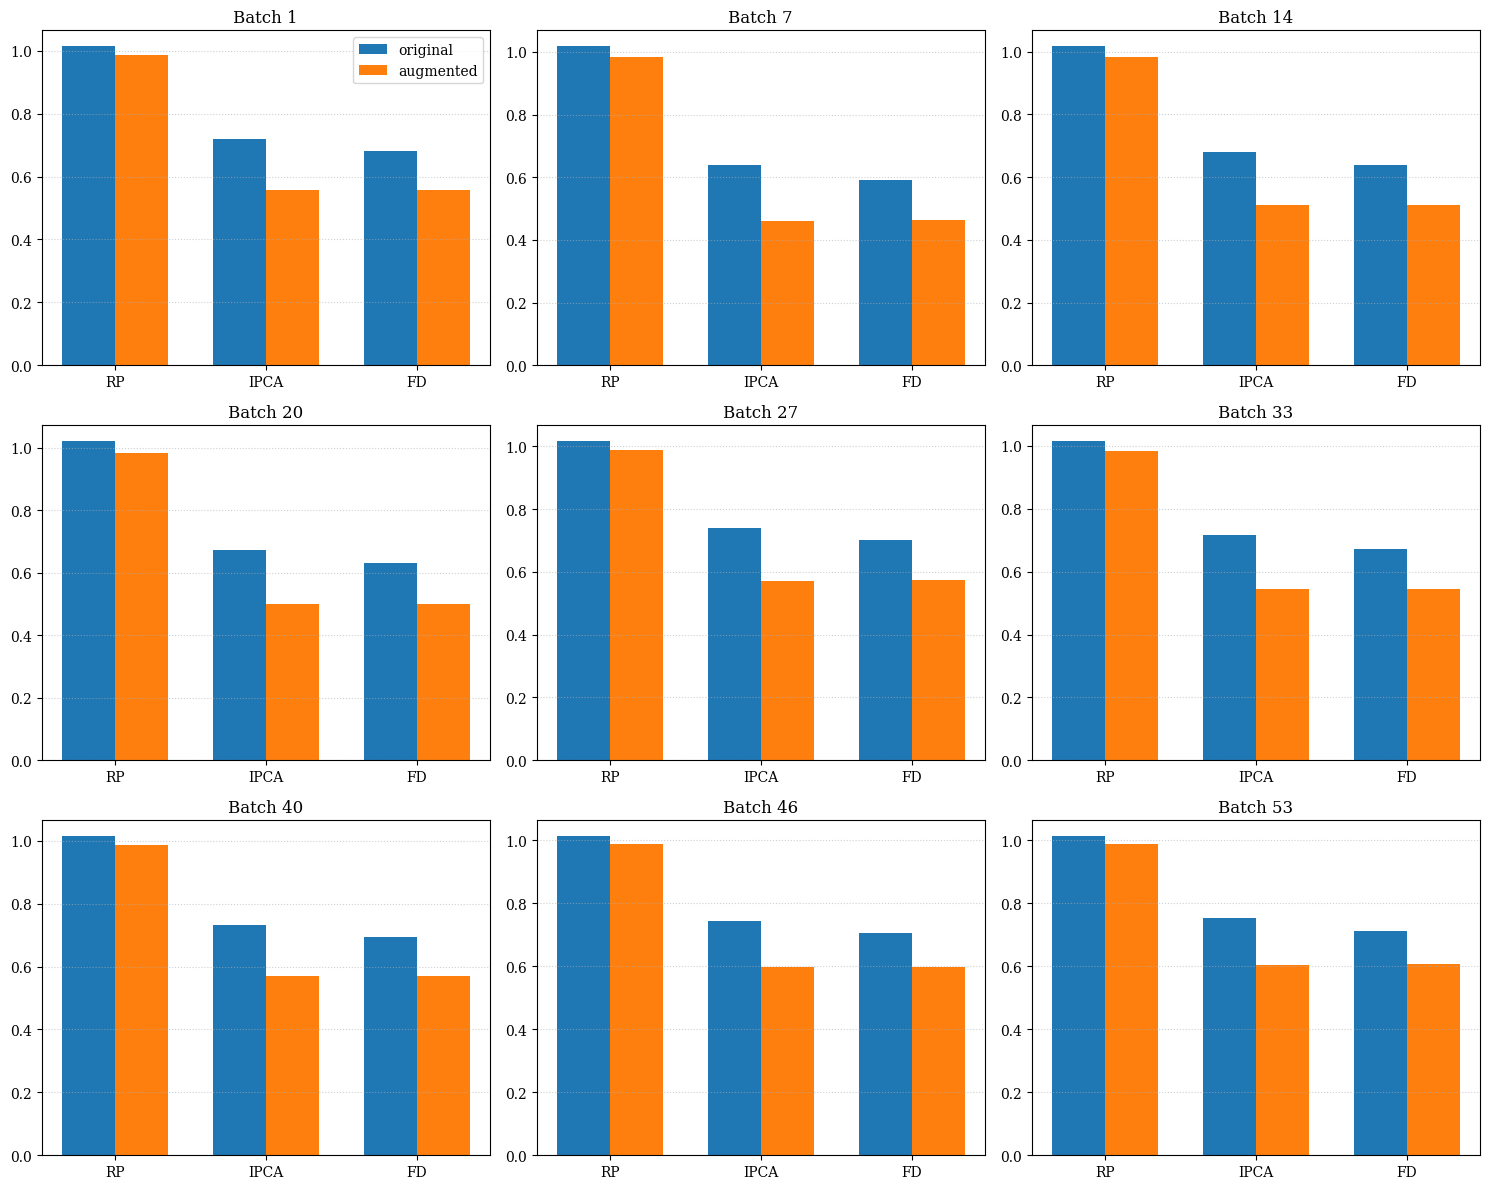

,batch,m_orig,m_aug,d,orig_recon_rp,orig_recon_ipca,orig_recon_fd,aug_recon_rp,aug_recon_ipca,aug_recon_fd,ratio_rp,ratio_ipca,ratio_fd,ev_rp_aug,ev_ipca_aug,ev_fd_aug
0,1,402,412,1712,1.014212,0.720188,0.681257,0.985914,0.557110,0.558274,0.972098,0.773562,0.819477,0.963094,0.680956,0.680180
1,7,206,216,1434,1.018062,0.638610,0.590472,0.983606,0.461806,0.463319,0.966155,0.723143,0.784658,0.939005,0.778950,0.778029
2,14,269,279,1433,1.017156,0.680826,0.637340,0.983514,0.510674,0.511958,0.966926,0.750080,0.803272,0.962248,0.730739,0.729853
3,20,248,258,1362,1.020141,0.672839,0.631412,0.983532,0.499699,0.500951,0.964114,0.742672,0.793383,0.891220,0.741367,0.740502
4,27,373,383,1649,1.015601,0.738425,0.701268,0.986354,0.571439,0.572703,0.971203,0.773861,0.816668,0.908112,0.664390,0.663455
5,33,325,335,1658,1.014946,0.715778,0.670651,0.985364,0.543906,0.545055,0.970854,0.759881,0.812725,0.976743,0.694649,0.693883
6,40,379,389,1795,1.014198,0.733549,0.694877,0.986476,0.569738,0.570713,0.972666,0.776687,0.821314,0.979363,0.666399,0.665685
7,46,429,439,2106,1.012223,0.744267,0.704433,0.989198,0.596516,0.597526,0.977252,0.801481,0.848237,0.912193,0.634013,0.633309
8,53,484,494,1989,1.012761,0.754370,0.712524,0.988234,0.604942,0.605791,0.975783,0.801917,0.850204,0.948484,0.624312,0.623621


In [ ]:
ANOMALY_BATCH_COUNT = 9
N_ANOM = 10
ANOM_TYPES = ['dense', 'rare_item', 'pattern_clone']
K = 50
FD_ELL = 50
RP_SEED = 42
BINARY_THRESHOLD = 0.5
DETECT_RATIO_THRESH = 1.5
DISPLAY_TOP = True

def build_basket_df(batch_df):
    basket = batch_df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack(fill_value=0)
    return (basket > 0).astype(int)

def generate_dense_invoice(d, density=0.6):
    k = max(1, int(math.ceil(d * density)))
    idx = np.random.choice(d, size=k, replace=False)
    vec = np.zeros(d, dtype=int)
    vec[idx] = 1
    return vec

def generate_rare_invoice(d, rare_idx_sorted, take=1):
    chosen = rare_idx_sorted[:max(1, take)]
    idx = np.random.choice(chosen, size=1, replace=False)
    vec = np.zeros(d, dtype=int)
    vec[idx] = 1
    return vec

def generate_clone_invoice(row):
    return row.astype(int)

def compute_rp_metrics(X, k, seed):
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    R = rng.normal(loc=0.0, scale=1.0/np.sqrt(max(1, k)), size=(d, k))
    X_proj = X @ R
    R_pinv = np.linalg.pinv(R)
    Xhat = X_proj @ R_pinv
    frob = np.linalg.norm(X, ord='fro')
    recon_err = np.linalg.norm(X - Xhat, ord='fro') / max(1e-12, frob)
    explained = np.sum(np.var(X_proj, axis=0, ddof=0)) / (np.sum(np.var(X, axis=0, ddof=0)) + 1e-12)
    return recon_err, explained

def compute_ipca_metrics(X, k):
    mean = X.mean(axis=0)
    Xc = X - mean
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    k_eff = min(k, Vt.shape[0])
    V_k = Vt[:k_eff, :].T
    Z = Xc @ V_k
    Xhat = (Z @ V_k.T) + mean
    frob = np.linalg.norm(X, ord='fro')
    recon_err = np.linalg.norm(X - Xhat, ord='fro') / max(1e-12, frob)
    explained = np.sum(np.var(Z, axis=0, ddof=0)) / (np.sum(np.var(X, axis=0, ddof=0)) + 1e-12)
    return recon_err, explained

def compute_fd_metrics(X, ell):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    ell_eff = min(ell, len(s))
    V_ell = Vt[:ell_eff, :].T
    Xhat = (X @ V_ell) @ V_ell.T
    frob = np.linalg.norm(X, ord='fro')
    recon_err = np.linalg.norm(X - Xhat, ord='fro') / max(1e-12, frob)
    explained = np.sum(np.var(X @ V_ell, axis=0, ddof=0)) / (np.sum(np.var(X, axis=0, ddof=0)) + 1e-12)
    return recon_err, explained

n_batches = len(batches)
if n_batches >= ANOMALY_BATCH_COUNT:
    batch_indices = np.unique(np.linspace(1, n_batches, ANOMALY_BATCH_COUNT, dtype=int))
else:
    batch_indices = np.arange(1, n_batches + 1)

anomaly_reports = []
plots = []
rng_global = np.random.default_rng(0)

for batch_idx in batch_indices:
    batch_df = batches[batch_idx - 1]
    basket_orig = build_basket_df(batch_df)
    items = list(basket_orig.columns)
    m_orig, d = basket_orig.shape
    if d == 0 or m_orig == 0:
        continue

    item_freq = basket_orig.sum(axis=0).values
    rare_idx_sorted = np.argsort(item_freq)

    new_invoices = []
    new_ids = []
    for j in range(N_ANOM):
        typ = ANOM_TYPES[j % len(ANOM_TYPES)]
        if typ == 'dense':
            vec = generate_dense_invoice(d, density=0.6)
        elif typ == 'rare_item':
            take = min(2, max(1, int(math.ceil(d * 0.01))))
            vec = generate_rare_invoice(d, rare_idx_sorted, take=take)
        else:
            sample_row = basket_orig.sample(1).values.flatten()
            vec = generate_clone_invoice(sample_row)
        new_invoices.append(vec)
        new_ids.append(f"ANOM_{batch_idx}_{j+1}")

    df_anom = pd.DataFrame(new_invoices, columns=items, index=new_ids)
    basket_aug = pd.concat([basket_orig, df_anom], axis=0).fillna(0).astype(int)

    X_orig = basket_orig.values.astype(float)
    X_aug = basket_aug.values.astype(float)

    k = min(K, d)
    ell = min(FD_ELL, d)

    if 'df_metrics' in globals() and isinstance(df_metrics, pd.DataFrame) and (df_metrics['batch'] == batch_idx).any():
        row = df_metrics[df_metrics['batch'] == batch_idx].iloc[0]
        orig_rp_err = float(row['rp_recon_err'])
        orig_ipca_err = float(row['ipca_recon_err'])
        orig_fd_err = float(row['fd_recon_err'])
    else:
        orig_rp_err, _ = compute_rp_metrics(X_orig, k, RP_SEED)
        orig_ipca_err, _ = compute_ipca_metrics(X_orig, k)
        orig_fd_err, _ = compute_fd_metrics(X_orig, ell)

    recon_rp_aug, ev_rp_aug = compute_rp_metrics(X_aug, k, RP_SEED)
    recon_ipca_aug, ev_ipca_aug = compute_ipca_metrics(X_aug, k)
    recon_fd_aug, ev_fd_aug = compute_fd_metrics(X_aug, ell)

    report = {
        'batch': int(batch_idx),
        'm_orig': int(m_orig),
        'm_aug': int(X_aug.shape[0]),
        'd': int(d),
        'orig_recon_rp': float(orig_rp_err),
        'orig_recon_ipca': float(orig_ipca_err),
        'orig_recon_fd': float(orig_fd_err),
        'aug_recon_rp': float(recon_rp_aug),
        'aug_recon_ipca': float(recon_ipca_aug),
        'aug_recon_fd': float(recon_fd_aug),
        'ratio_rp': float(recon_rp_aug / orig_rp_err) if orig_rp_err > 0 else np.nan,
        'ratio_ipca': float(recon_ipca_aug / orig_ipca_err) if orig_ipca_err > 0 else np.nan,
        'ratio_fd': float(recon_fd_aug / orig_fd_err) if orig_fd_err > 0 else np.nan,
        'ev_rp_aug': float(ev_rp_aug),
        'ev_ipca_aug': float(ev_ipca_aug),
        'ev_fd_aug': float(ev_fd_aug)
    }
    anomaly_reports.append(report)

    methods = ['RP', 'IPCA', 'FD']
    orig_vals = [report['orig_recon_rp'], report['orig_recon_ipca'], report['orig_recon_fd']]
    aug_vals = [report['aug_recon_rp'], report['aug_recon_ipca'], report['aug_recon_fd']]

    plots.append((batch_idx, orig_vals, aug_vals))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for ax_idx, (batch_idx, orig_vals, aug_vals) in enumerate(plots):
    ax = axes[ax_idx]
    x = np.arange(3)
    width = 0.35
    ax.bar(x - width/2, orig_vals, width, label='original')
    ax.bar(x + width/2, aug_vals, width, label='augmented')
    ax.set_xticks(x)
    ax.set_xticklabels(['RP', 'IPCA', 'FD'])
    ax.set_title(f'Batch {batch_idx}')
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    if ax_idx == 0:
        ax.legend()
for k_ax in range(len(plots), 9):
    axes[k_ax].axis('off')
plt.tight_layout()
plt.show()

df_anom_report = pd.DataFrame(anomaly_reports).sort_values('batch').reset_index(drop=True)
display(df_anom_report)


<font face="Book Antiqua">

# Step 9 – Summary & Conclusion

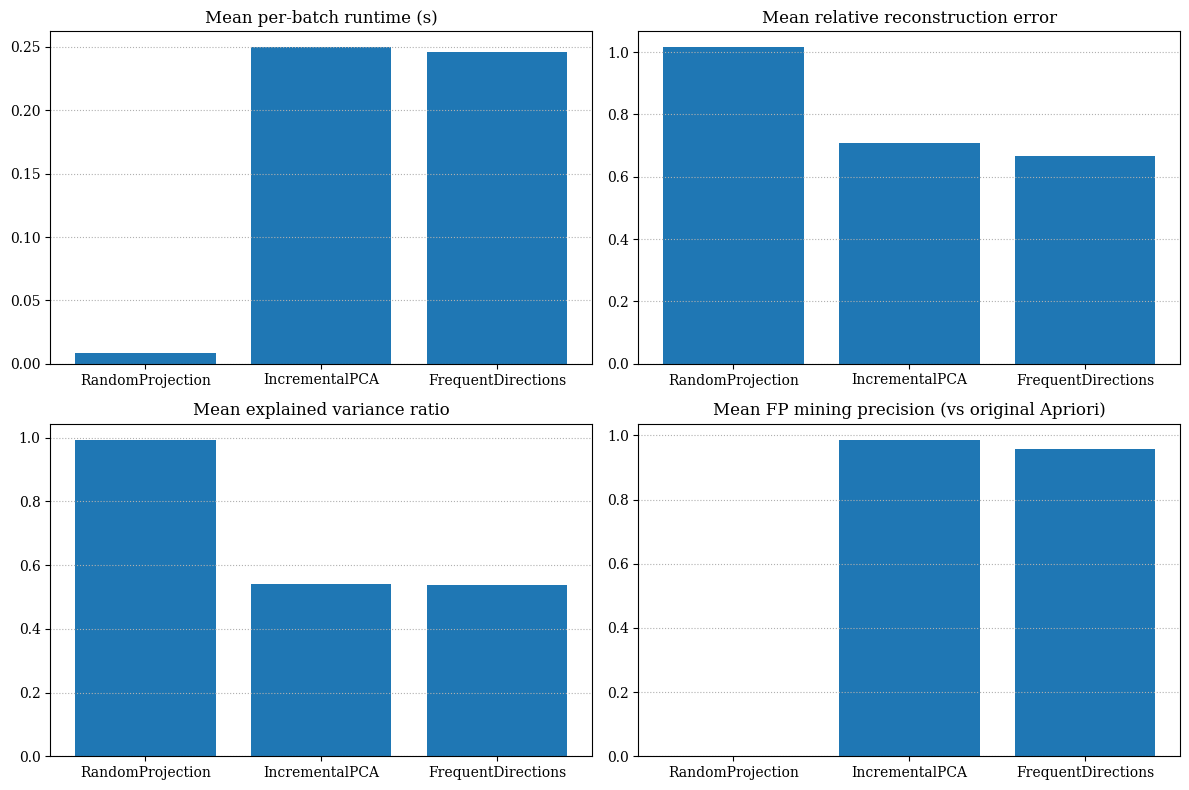

,method,mean_time_s,median_time_s,mean_recon_err,mean_explained_var,stab_ev_std,stab_err_std,fp_mean_prec,fp_mean_rec,anom_mean_ratio
0,RandomProjection,0.008861,0.007080,1.015732,0.994124,0.016638,0.002924,0.000000,0.000000,0.970783
1,IncrementalPCA,0.249857,0.147232,0.709351,0.540048,0.076214,0.056026,0.986617,0.312415,0.767032
2,FrequentDirections,0.246259,0.170670,0.667082,0.538821,0.076046,0.061663,0.956272,0.487601,0.816660


In [ ]:
df_metrics = globals().get('df_metrics', None)
summary = globals().get('summary', None)
df_fp_compare = globals().get('df_fp_compare', None)
df_anom_report = globals().get('df_anom_report', None)

runtime_stats = {}
if df_metrics is not None:
    mapping = [('rp_time', 'RandomProjection'), ('ipca_time', 'IncrementalPCA'), ('fd_time', 'FrequentDirections')]
    for col, label in mapping:
        if col in df_metrics.columns:
            runtime_stats[label] = {'mean_s': float(df_metrics[col].mean()), 'median_s': float(df_metrics[col].median()), 'std_s': float(df_metrics[col].std())}
        else:
            runtime_stats[label] = {'mean_s': np.nan, 'median_s': np.nan, 'std_s': np.nan}
else:
    runtime_stats = {'RandomProjection': {'mean_s': np.nan}, 'IncrementalPCA': {'mean_s': np.nan}, 'FrequentDirections': {'mean_s': np.nan}}

acc_stats = {}
if df_metrics is not None:
    mapping = [('rp_recon_err', 'RandomProjection'), ('ipca_recon_err', 'IncrementalPCA'), ('fd_recon_err', 'FrequentDirections')]
    for col, label in mapping:
        if col in df_metrics.columns:
            acc_stats[label] = {'mean_recon_err': float(df_metrics[col].mean()), 'median_recon_err': float(df_metrics[col].median()), 'std_recon_err': float(df_metrics[col].std())}
        else:
            acc_stats[label] = {'mean_recon_err': np.nan, 'median_recon_err': np.nan, 'std_recon_err': np.nan}
else:
    acc_stats = {'RandomProjection': {'mean_recon_err': np.nan}, 'IncrementalPCA': {'mean_recon_err': np.nan}, 'FrequentDirections': {'mean_recon_err': np.nan}}

ev_stats = {}
if df_metrics is not None:
    mapping = [('rp_explained_var', 'RandomProjection'), ('ipca_explained_var', 'IncrementalPCA'), ('fd_explained_var', 'FrequentDirections')]
    for col, label in mapping:
        if col in df_metrics.columns:
            ev_stats[label] = {'mean_ev': float(df_metrics[col].mean()), 'median_ev': float(df_metrics[col].median()), 'std_ev': float(df_metrics[col].std())}
        else:
            ev_stats[label] = {'mean_ev': np.nan, 'median_ev': np.nan, 'std_ev': np.nan}
else:
    ev_stats = {'RandomProjection': {'mean_ev': np.nan}, 'IncrementalPCA': {'mean_ev': np.nan}, 'FrequentDirections': {'mean_ev': np.nan}}

comp_stats = {'mean_k_over_d': np.nan, 'median_k_over_d': np.nan}
if summary is not None:
    ratios = []
    for s in summary:
        d = s.get('cols') if isinstance(s, dict) else None
        if d is None:
            d = s.get('n_cols') if isinstance(s, dict) else None
        k = s.get('k') if isinstance(s, dict) else None
        if k is None:
            if isinstance(s, dict) and 'X_rp' in s and isinstance(s['X_rp'], np.ndarray):
                k = s['X_rp'].shape[1]
            elif isinstance(s, dict) and 'X_ipca' in s and isinstance(s['X_ipca'], np.ndarray):
                k = s['X_ipca'].shape[1]
        if (k is not None) and (d not in [None, 0, np.nan]):
            ratios.append(float(k) / float(d))
    if len(ratios) > 0:
        comp_stats['mean_k_over_d'] = float(np.mean(ratios))
        comp_stats['median_k_over_d'] = float(np.median(ratios))
        comp_stats['ratios_list'] = ratios

method_map = {'RandomProjection': ('rp_explained_var', 'rp_recon_err'), 'IncrementalPCA': ('ipca_explained_var', 'ipca_recon_err'), 'FrequentDirections': ('fd_explained_var', 'fd_recon_err')}
stab_stats = {}
for label, (ev_col, err_col) in method_map.items():
    if df_metrics is not None and ev_col in df_metrics.columns and err_col in df_metrics.columns:
        ev_series = df_metrics[ev_col].dropna()
        err_series = df_metrics[err_col].dropna()
        ev_std = float(ev_series.std()) if not ev_series.empty else np.nan
        ev_cv = float(ev_series.std() / ev_series.mean()) if (not ev_series.empty and ev_series.mean() != 0) else np.nan
        err_std = float(err_series.std()) if not err_series.empty else np.nan
        err_cv = float(err_series.std() / err_series.mean()) if (not err_series.empty and err_series.mean() != 0) else np.nan
        stab_stats[label] = {'ev_std': ev_std, 'ev_cv': ev_cv, 'err_std': err_std, 'err_cv': err_cv}
    else:
        stab_stats[label] = {'ev_std': np.nan, 'ev_cv': np.nan, 'err_std': np.nan, 'err_cv': np.nan}

fp_stats = {}
if df_fp_compare is not None:
    for method_prefix, label in [('rp', 'RandomProjection'), ('ipca', 'IncrementalPCA'), ('fd', 'FrequentDirections')]:
        prec_col = f'{method_prefix}_apriori_prec'
        rec_col = f'{method_prefix}_apriori_rec'
        f1_col = f'{method_prefix}_apriori_f1'
        if prec_col in df_fp_compare.columns:
            fp_stats[label] = {'mean_prec': float(df_fp_compare[prec_col].mean()), 'mean_rec': float(df_fp_compare[rec_col].mean()), 'mean_f1': float(df_fp_compare[f1_col].mean())}
        else:
            fp_stats[label] = {'mean_prec': np.nan, 'mean_rec': np.nan, 'mean_f1': np.nan}
else:
    fp_stats = {'RandomProjection': {'mean_prec': np.nan}, 'IncrementalPCA': {'mean_prec': np.nan}, 'FrequentDirections': {'mean_prec': np.nan}}

anom_stats = {}
if df_anom_report is not None:
    for method in ['rp', 'ipca', 'fd']:
        key = f'ratio_{method}'
        if key in df_anom_report.columns:
            ratios = df_anom_report[key].dropna()
            anom_stats[method.upper()] = {'mean_ratio': float(ratios.mean()) if len(ratios)>0 else np.nan, 'max_ratio': float(ratios.max()) if len(ratios)>0 else np.nan}
        else:
            anom_stats[method.upper()] = {'mean_ratio': np.nan, 'max_ratio': np.nan}
else:
    anom_stats = {'RP': {'mean_ratio': np.nan}, 'IPCA': {'mean_ratio': np.nan}, 'FD': {'mean_ratio': np.nan}}

summary_rows = []
methods = ['RandomProjection', 'IncrementalPCA', 'FrequentDirections']
for m in methods:
    row = {'method': m,
           'mean_time_s': runtime_stats.get(m, {}).get('mean_s', np.nan),
           'median_time_s': runtime_stats.get(m, {}).get('median_s', np.nan),
           'mean_recon_err': acc_stats.get(m, {}).get('mean_recon_err', np.nan),
           'mean_explained_var': ev_stats.get(m, {}).get('mean_ev', np.nan),
           'stab_ev_std': stab_stats.get(m, {}).get('ev_std', np.nan),
           'stab_err_std': stab_stats.get(m, {}).get('err_std', np.nan),
           'fp_mean_prec': fp_stats.get(m, {}).get('mean_prec', np.nan),
           'fp_mean_rec': fp_stats.get(m, {}).get('mean_rec', np.nan),
           'anom_mean_ratio': anom_stats.get('RP' if m=='RandomProjection' else ('IPCA' if m=='IncrementalPCA' else 'FD'), {}).get('mean_ratio', np.nan)}
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

fig, axs = plt.subplots(2, 2, figsize=(12,8))
axs[0,0].bar(df_summary['method'], df_summary['mean_time_s'])
axs[0,0].set_title('Mean per-batch runtime (s)')
axs[0,0].grid(axis='y', linestyle=':')
axs[0,1].bar(df_summary['method'], df_summary['mean_recon_err'])
axs[0,1].set_title('Mean relative reconstruction error')
axs[0,1].grid(axis='y', linestyle=':')
axs[1,0].bar(df_summary['method'], df_summary['mean_explained_var'])
axs[1,0].set_title('Mean explained variance ratio')
axs[1,0].grid(axis='y', linestyle=':')
axs[1,1].bar(df_summary['method'], df_summary['fp_mean_prec'])
axs[1,1].set_title('Mean FP mining precision (vs original Apriori)')
axs[1,1].grid(axis='y', linestyle=':')
plt.tight_layout()
plt.show()

display(df_summary)